In [9]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def segment_audio(y, sr, segment_seconds=3):
    seg_len = int(segment_seconds * sr)
    n_segments = len(y) // seg_len

    segments = np.array([
        y[i*seg_len:(i+1)*seg_len]
        for i in range(n_segments)
    ])

    return segments  # shape = (n_segments, 66150)


In [4]:
def mfcc_3s(segment, sr=22050):
    mfcc = librosa.feature.mfcc(
        y=segment,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mfcc=13,
        n_mels=1024,
        window="hamming"
    )
    return mfcc.T       # final shape: (130, 13)


In [5]:
def compute_mfcc_segments(segments, sr=22050):
    mfcc_list = []
    for seg in segments:
        mfcc = mfcc_3s(seg, sr)  # shape (130, 13)
        mfcc_list.append(mfcc)
    return np.array(mfcc_list)   # shape (n_segments, 130, 13)


In [6]:
def process_file(file_path, sr=22050):
    # Load audio
    y, sr = librosa.load(file_path, sr=sr)
    
    # Split into 3-second fixed windows
    segments = segment_audio(y, sr)
    
    # Compute MFCC for each 3s segment
    mfccs = compute_mfcc_segments(segments, sr)
    
    return mfccs


In [11]:
dataset_folder = "./dataverse_files"
OWN_path = "./dataverse_files/OWN"
file_name = "0001.mp3"
file_path = f"{OWN_path}/{file_name}"
mfccs = process_file(file_path)
print(mfccs.shape)  # (n_segments, 130, 13)


(10, 130, 13)


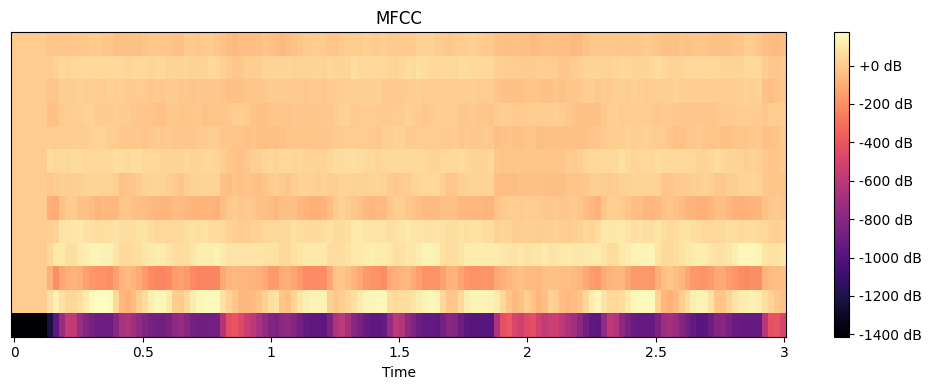

In [14]:
import librosa.display
import matplotlib.pyplot as plt

def plot_mfcc(mfcc, sr=22050, hop_length=512):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        mfcc,
        x_axis='time',
        sr=sr,
        hop_length=hop_length,
        cmap='magma'
    )
    plt.colorbar(format="%+2.f dB")
    plt.title("MFCC")
    plt.tight_layout()
    plt.show()
    
plot_mfcc(mfccs[0].T)  # Plot MFCC of the first segment
